## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

In [2]:
df = pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")

## Dataset Overview

In [3]:
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [4]:
df.shape

(3000, 10)

In [5]:
df.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [7]:
df.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


In [8]:
df.describe(include="object")

,Country,Attack Type,Target Industry,Attack Source,Security Vulnerability Type,Defense Mechanism Used
count,3000,3000,3000,3000,3000,3000
unique,10,6,7,4,4,5
top,UK,DDoS,IT,Nation-state,Zero-day,Antivirus
freq,321,531,478,794,785,628


In [9]:
df.duplicated().sum()

0

## Exploring Categorical Features

### The frequency of important categorical variables is calculated using `value_counts()`.

#### The following features are analyzed:

#### - Attack Type
#### - Target Industry
#### - Country
#### - Attack Source
#### - Security Vulnerability Type
#### - Defense Mechanism Used

In [10]:
df["Attack Type"].value_counts()

Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64

In [11]:
df["Target Industry"].value_counts()

Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Telecommunications    403
Government            403
Name: count, dtype: int64

In [12]:
df["Country"].value_counts()

Country
UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64

In [13]:
df["Attack Source"].value_counts()

Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64

In [14]:
df["Security Vulnerability Type"].value_counts()

Security Vulnerability Type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: count, dtype: int64

In [15]:
df["Defense Mechanism Used"].value_counts()

Defense Mechanism Used
Antivirus             628
VPN                   612
Encryption            592
Firewall              585
AI-based Detection    583
Name: count, dtype: int64

## Correlation Analysis
#### correlation matrix Between Numerical Features

In [16]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.corr()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
Year,1.000000,0.010581,0.002317,-0.004982
Financial Loss (in Million $),0.010581,1.000000,0.001787,-0.012671
Number of Affected Users,0.002317,0.001787,1.000000,0.005893
Incident Resolution Time (in Hours),-0.004982,-0.012671,0.005893,1.000000


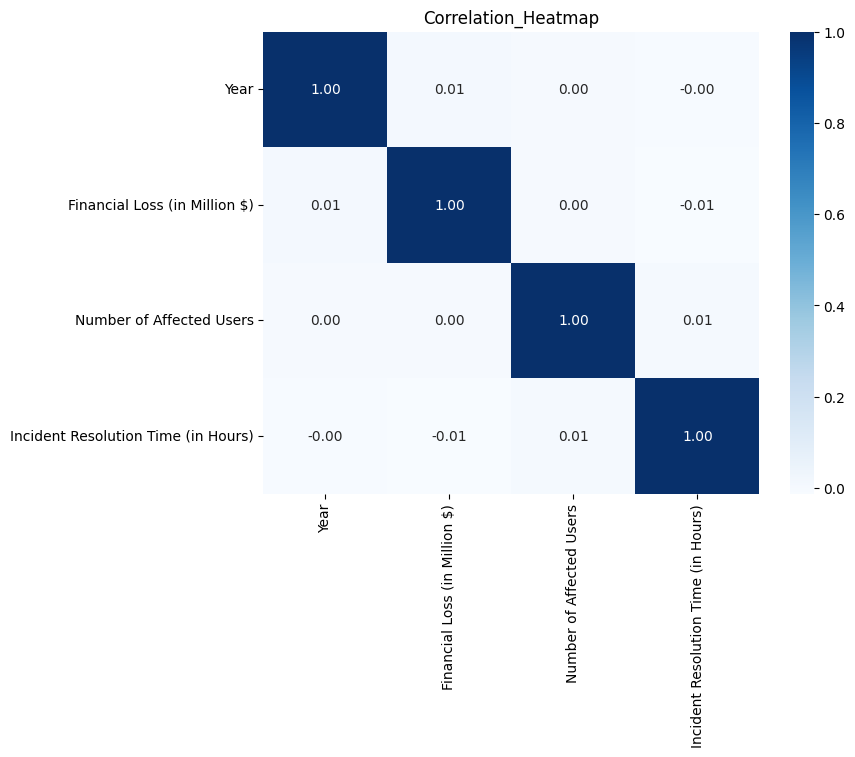

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation_Heatmap")
plt.show()

## Data Visualization

### 1. Distribution of Cyber Attack Types
#### Frequency of different cyber attack types in the dataset.

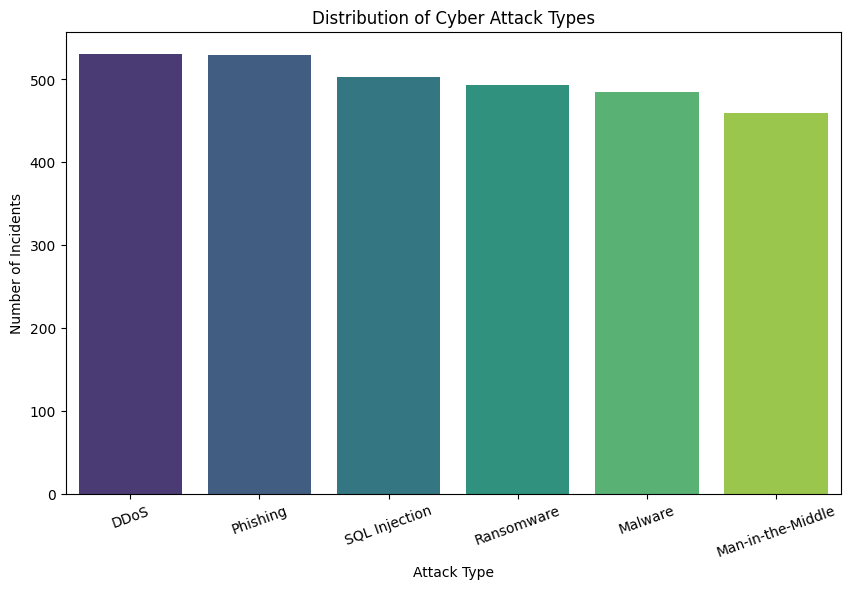

In [18]:
attack_counts = (
    df["Attack Type"]
    .value_counts()
    .reset_index()
)

attack_counts.columns = ["Attack Type", "Count"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=attack_counts,
    x="Attack Type",
    y="Count",
    hue="Attack Type",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Cyber Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=20)

plt.show()

## 2. Cyber Attacks by Target Industry

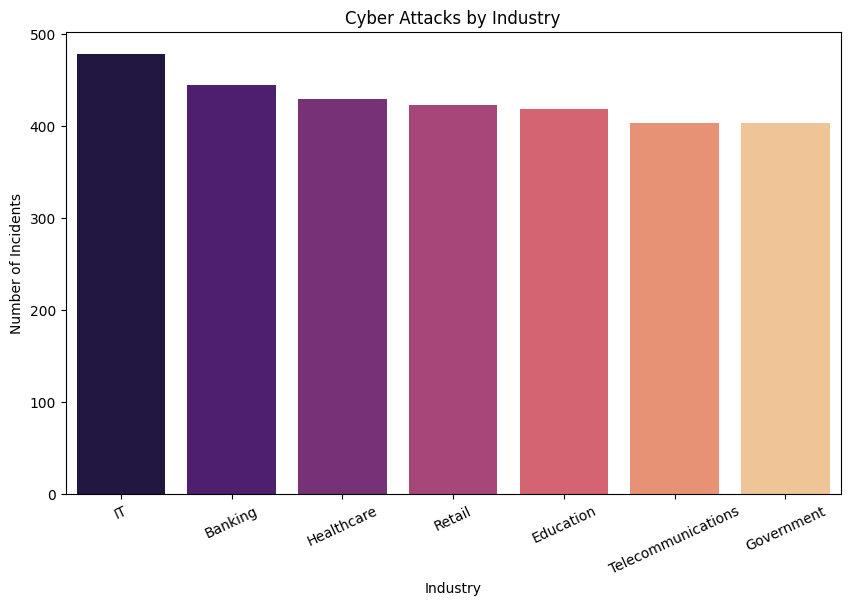

In [19]:
industry_counts = (
    df["Target Industry"]
    .value_counts()
    .reset_index()
)

industry_counts.columns = ["Target Industry", "Count"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=industry_counts,
    x="Target Industry",
    y="Count",
    hue="Target Industry",
    palette="magma",
    legend=False
)

plt.title("Cyber Attacks by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=25)

plt.show()

## 3: Attack Trend Over Years

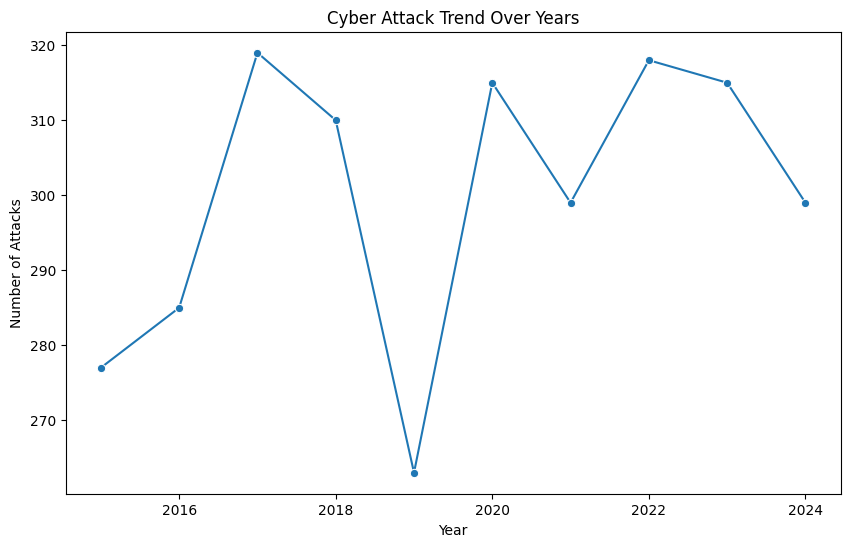

In [20]:
yearly_attacks = df.groupby("Year").size().reset_index(name="Total Attacks")

plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_attacks,
    x="Year",
    y="Total Attacks",
    marker="o"
)

plt.title("Cyber Attack Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.show()

## 4: Financial Loss by Target Industry
#### The total financial loss caused by cyber attacks

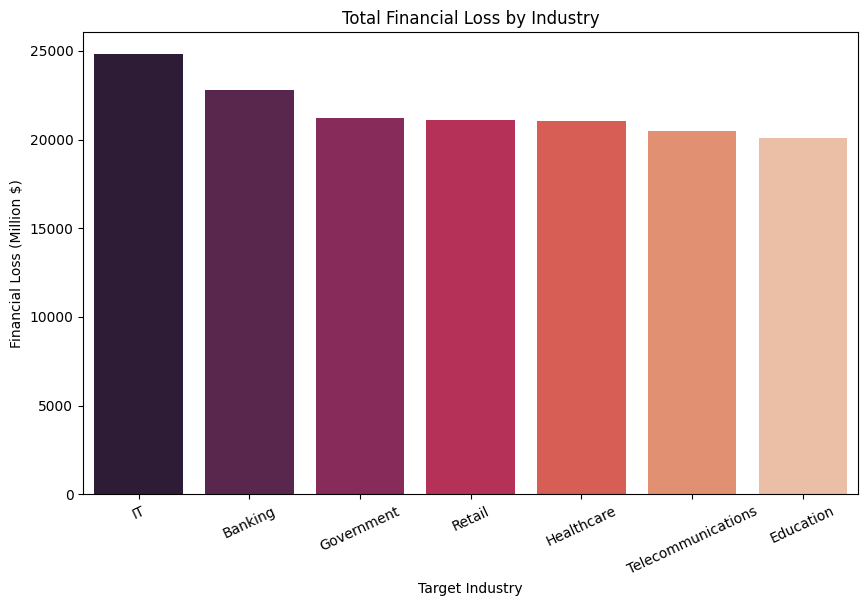

In [21]:
industry_loss = (
    df.groupby("Target Industry")["Financial Loss (in Million $)"]
    .sum()
    .reset_index()
    .sort_values(by="Financial Loss (in Million $)", ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=industry_loss,
    x="Target Industry",
    y="Financial Loss (in Million $)",
    hue="Target Industry",
    palette="rocket",
    legend=False
)

plt.title("Total Financial Loss by Industry")
plt.xlabel("Target Industry")
plt.ylabel("Financial Loss (Million $)")
plt.xticks(rotation=25)

plt.show()

## 5: Attack Type vs Target Industry (Heatmap)
#### different cyber attack types across industries.

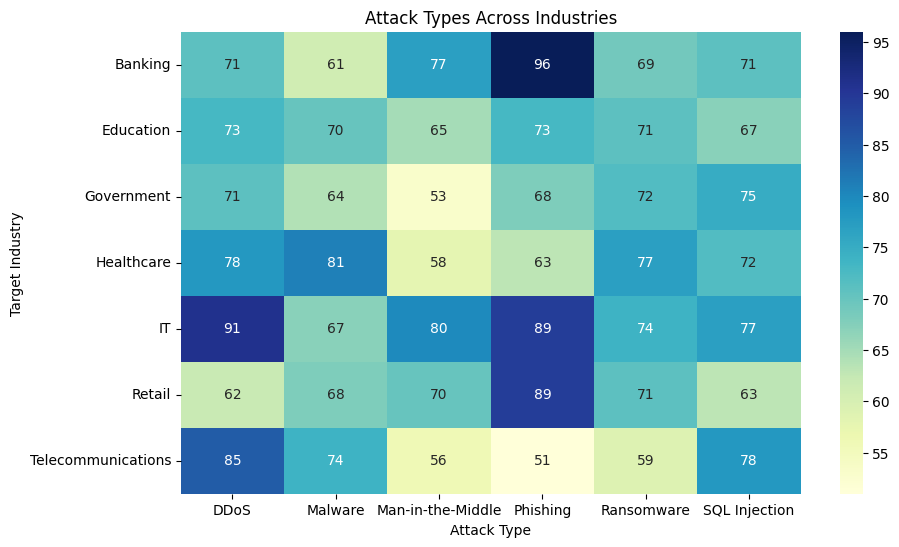

In [22]:
attack_industry = pd.crosstab(df["Target Industry"], df["Attack Type"])

plt.figure(figsize=(10,6))

sns.heatmap(
    attack_industry,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Attack Types Across Industries")
plt.xlabel("Attack Type")
plt.ylabel("Target Industry")

plt.show()

## 6: Defense Mechanism Used
#### the frequency of different cybersecurity defense mechanisms used to prevent attacks.

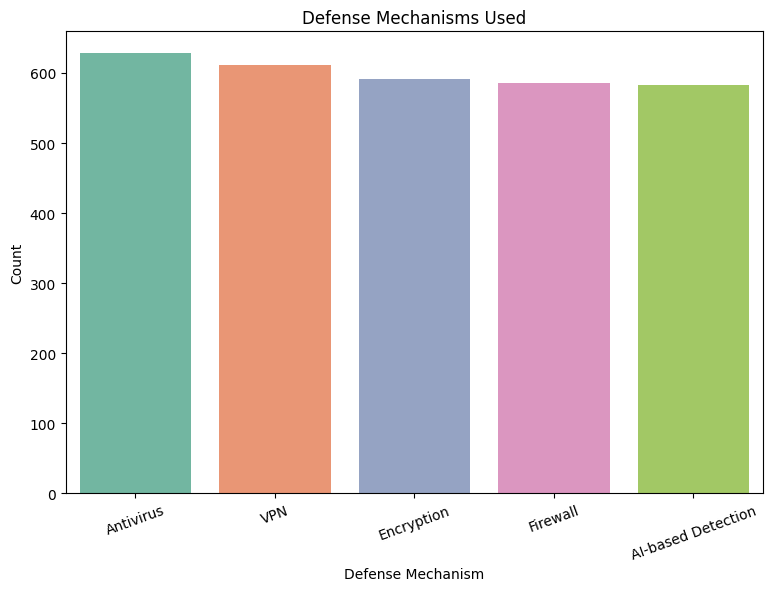

In [23]:
defense_counts = (
    df["Defense Mechanism Used"]
    .value_counts()
    .reset_index()
)

defense_counts.columns = ["Defense Mechanism Used", "Count"]

plt.figure(figsize=(9,6))

sns.barplot(
    data=defense_counts,
    x="Defense Mechanism Used",
    y="Count",
    hue="Defense Mechanism Used",
    palette="Set2",
    legend=False
)

plt.title("Defense Mechanisms Used")
plt.xlabel("Defense Mechanism")
plt.ylabel("Count")
plt.xticks(rotation=20)

plt.show()

## 7. Incident Resolution Time Distribution

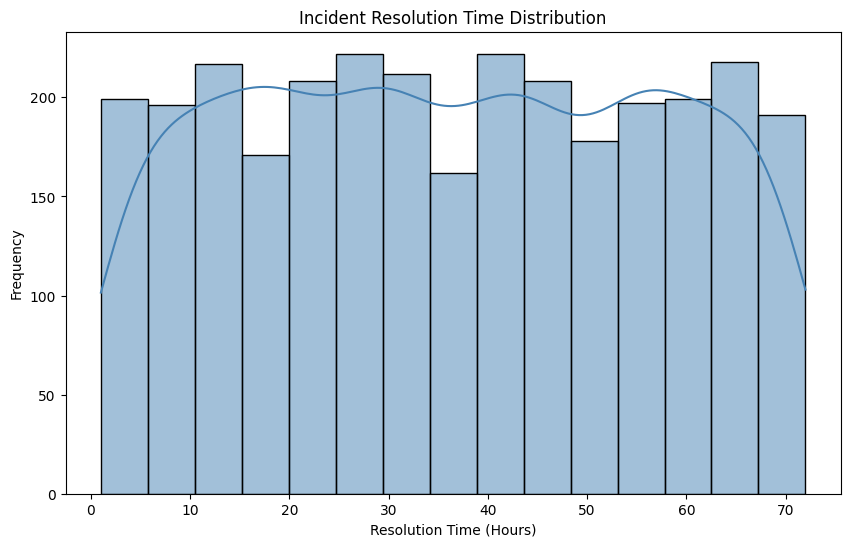

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Incident Resolution Time (in Hours)"],
    bins=15,
    kde=True,
    color="steelblue"
)

plt.title("Incident Resolution Time Distribution")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Frequency")

plt.show()

## 8: Top Countries by Financial Loss

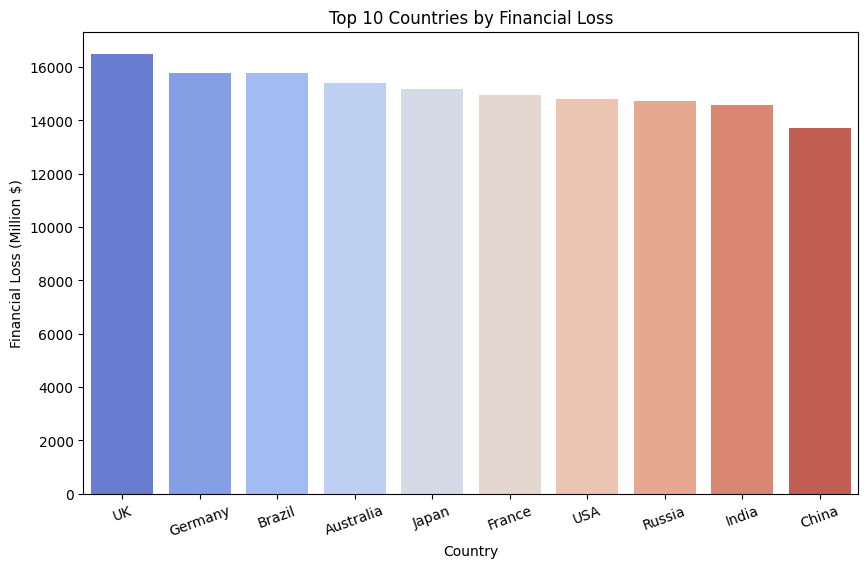

In [26]:
country_loss = (
    df.groupby("Country")["Financial Loss (in Million $)"]
    .sum()
    .reset_index()
    .sort_values(by="Financial Loss (in Million $)", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=country_loss,
    x="Country",
    y="Financial Loss (in Million $)",
    hue="Country",
    palette="coolwarm",
    legend=False
)

plt.title("Top 10 Countries by Financial Loss")
plt.xlabel("Country")
plt.ylabel("Financial Loss (Million $)")
plt.xticks(rotation=20)

plt.show()

## Conclusion

### This project provides insights into global cybersecurity threats from 2015 to 2024.

#### Key findings include:

- Different attack types occur with varying frequencies.
- Some industries experience significantly more cyber attacks than others.
- Financial losses differ across industries.
- Cyber attack trends change over the years.
- Organizations use different defense mechanisms to reduce cyber risks.
- Incident resolution time varies across different cybersecurity events.

The analysis demonstrates how Python data analysis and visualization techniques can be used to identify cybersecurity patterns and support better security decision-making.